# Linear Transformations
**Volume 1: Mathematical Analysis**

A **linear transformation** is a map $L: V \to W$ between vector spaces that preserves addition and scalar multiplication:
$$L(a\mathbf{x}_1 + b\mathbf{x}_2) = aL(\mathbf{x}_1) + bL(\mathbf{x}_2)$$

Every linear transformation from $\mathbb{R}^n$ to $\mathbb{R}^m$ corresponds to an $m \times n$ matrix $A$, applied via left multiplication $A\mathbf{x} = \mathbf{x}'$.

In this lab we visualize transformations using a coordinate array (the columns are 2D points forming a horse shape), apply transformations to it by left-multiplying, and analyze the computational performance of matrix operations.

In [7]:
import time
import numpy as np
from random import random
from matplotlib import pyplot as plt

## Loading and Plotting the Horse

The file `data/horse.npy` contains a $(2, n)$ array whose columns are 2D coordinate pairs. Plotting column 0 (x) against column 1 (y) draws the horse.

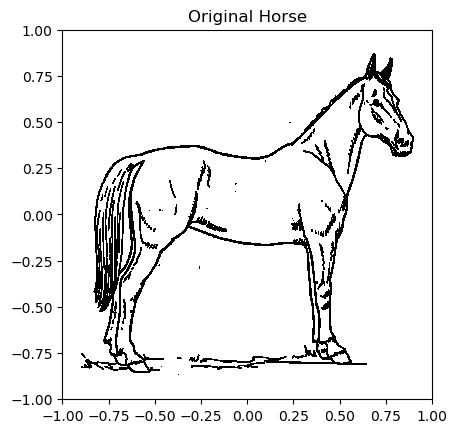

In [8]:
data = np.load("data/horse.npy")
plt.plot(data[0], data[1], 'k,')
plt.axis([-1, 1, -1, 1])
plt.gca().set_aspect("equal")
plt.title("Original Horse")
plt.show()

## Types of Linear Transformations in $\mathbb{R}^2$

All four transformation types below are $2 \times 2$ matrices applied via left multiplication to the $(2, n)$ data array.

### Stretch / Dilation
Scale by $a$ in the $x$-direction and $b$ in the $y$-direction:
$$A = \begin{pmatrix} a & 0 \\ 0 & b \end{pmatrix}$$
When $a = b$ this is called a *dilation*.

### Shear
Slant points horizontally (parameter $a$) or vertically (parameter $b$):
$$A = \begin{pmatrix} 1 & a \\ b & 1 \end{pmatrix}$$

### Reflection
Reflect about the line through the origin spanned by $(a, b)^\top$:
$$A = \frac{1}{a^2 + b^2}\begin{pmatrix} a^2 - b^2 & 2ab \\ 2ab & b^2 - a^2 \end{pmatrix}$$

### Rotation
Rotate counterclockwise by $\theta$ radians:
$$A = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$$

## Problem 1

Write four functions that each apply one of the transformation types above to an array $A$ of 2D column vectors. Then use each function to transform the horse data and display the original and transformed images side by side.

- `stretch(A, a, b)`: Scale by $a$ in $x$ and $b$ in $y$.
- `shear(A, a, b)`: Shear by $a$ horizontally and $b$ vertically.
- `reflect(A, a, b)`: Reflect about the line through the origin and $(a, b)$.
- `rotate(A, theta)`: Rotate counterclockwise by `theta` radians.

In [9]:
def stretch(A, a, b):
    """Scale the points in A by a in the x direction and b in the y direction.

    Parameters:
        A ((2,n) ndarray): Array containing points in R2 stored as columns.
        a (float): scaling factor in the x direction.
        b (float): scaling factor in the y direction.
    Return:
        ((2,n) ndarray): Transformed matrix
    """
    return np.array([[a, 0],
                     [0, b]]) @ A


def shear(A, a, b):
    """Slant the points in A by a in the x direction and b in the y direction.

    Parameters:
        A ((2,n) ndarray): Array containing points in R2 stored as columns.
        a (float): scaling factor in the x direction.
        b (float): scaling factor in the y direction.
    Return:
        ((2,n) ndarray): Transformed matrix
    """
    return np.array([[1, a],
                     [b, 1]]) @ A


def reflect(A, a, b):
    """Reflect the points in A about the line that passes through the origin
    and the point (a, b).

    Parameters:
        A ((2,n) ndarray): Array containing points in R2 stored as columns.
        a (float): x-coordinate of a point on the reflecting line.
        b (float): y-coordinate of the same point on the reflecting line.
    Return:
        ((2,n) ndarray): Transformed matrix
    """
    denom = a**2 + b**2
    return (1 / denom) * np.array([[a**2 - b**2, 2*a*b],
                                   [2*a*b,       b**2 - a**2]]) @ A


def rotate(A, theta):
    """Rotate the points in A about the origin by theta radians.

    Parameters:
        A ((2,n) ndarray): Array containing points in R2 stored as columns.
        theta (float): The rotation angle in radians.
    Return:
        ((2,n) ndarray): Transformed matrix
    """
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]]) @ A

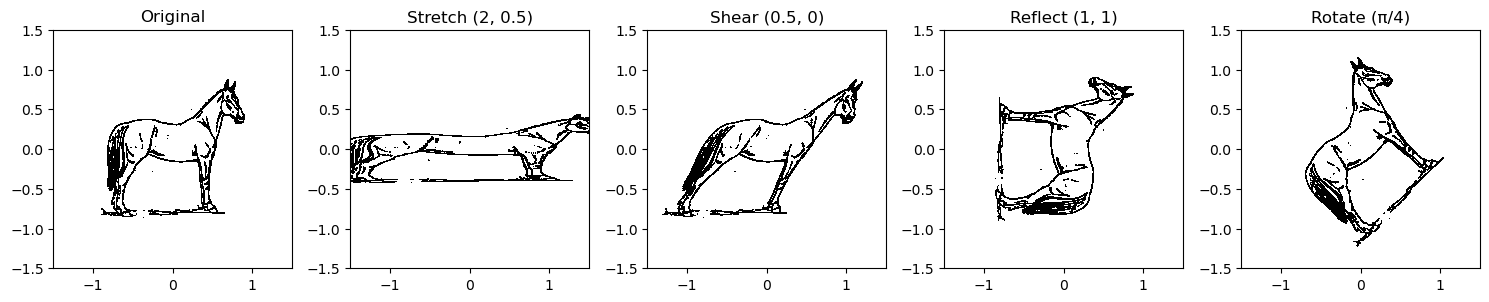

In [10]:
horse = np.load("data/horse.npy")

transforms = [
    ("Original",         horse),
    ("Stretch (2, 0.5)", stretch(horse, 2, 0.5)),
    ("Shear (0.5, 0)",   shear(horse, 0.5, 0)),
    ("Reflect (1, 1)",   reflect(horse, 1, 1)),
    ("Rotate (π/4)",     rotate(horse, np.pi / 4)),
]

fig, axes = plt.subplots(1, len(transforms), figsize=(15, 3))
for ax, (title, H) in zip(axes, transforms):
    ax.plot(H[0], H[1], 'k,')
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis([-1.5, 1.5, -1.5, 1.5])
plt.tight_layout()
plt.show()

## Affine Transformations and Modeling Motion

An **affine transformation** combines a linear transformation with a translation:
$$f(\mathbf{x}) = A\mathbf{x} + \mathbf{b}$$
This allows us to model motion where an object rotates *and* moves through space.

### Solar System Model

We model the Earth orbiting the Sun and the Moon orbiting the Earth.

- At time $t = 0$ the Earth is at $(x_e, 0)$ and the Moon is at $(x_m, 0)$.
- The Earth rotates around the Sun with angular velocity $\omega_e$, so its position at time $t$ is:
$$\mathbf{p}_e(t) = R(\omega_e t)\, \begin{pmatrix} x_e \\ 0 \end{pmatrix}$$
where $R(\theta)$ is the rotation matrix for angle $\theta$.
- The Moon rotates around the Earth with angular velocity $\omega_m$, so its position at time $t$ is the Earth's position plus the Moon's rotated offset from the Earth:
$$\mathbf{p}_m(t) = \mathbf{p}_e(t) + R(\omega_m t)\, \begin{pmatrix} x_m - x_e \\ 0 \end{pmatrix}$$

This is an affine transformation: the moon's position = (rotation of relative offset) + (translation to Earth).

## Problem 2

Implement `solar_system(T, x_e, x_m, omega_e, omega_m)` to plot the trajectories of the Earth and Moon over the time interval $[0, T]$, given:
- Initial Earth position: $(x_e, 0)$
- Initial Moon position: $(x_m, 0)$
- Earth angular velocity: $\omega_e$
- Moon angular velocity: $\omega_m$

Use a fine time grid, compute positions via rotation matrices (affine transformations), and plot both trajectories on the same axes. Mark the initial positions with a dot.

Test with: `solar_system(3*np.pi, 10, 11, 1, 13)`

In [11]:
def solar_system(T, x_e, x_m, omega_e, omega_m):
    """Plot the trajectories of the earth and moon over the time interval [0,T]
    assuming the initial position of the earth is (x_e, 0) and the initial
    position of the moon is (x_m, 0).

    Parameters:
        T (float): The final time.
        x_e (float): The earth's initial x coordinate.
        x_m (float): The moon's initial x coordinate.
        omega_e (float): The earth's angular velocity.
        omega_m (float): The moon's angular velocity.
    """
    times = np.linspace(0, T, 1000)

    earth_pos = np.array([rotate(np.array([[x_e], [0]]), omega_e * t).flatten()
                          for t in times])  # shape (1000, 2)

    offset = np.array([[x_m - x_e], [0]])
    moon_pos = np.array([earth_pos[i] + rotate(offset, omega_m * t).flatten()
                         for i, t in enumerate(times)])  # shape (1000, 2)

    plt.figure(figsize=(7, 7))
    plt.plot(earth_pos[:, 0], earth_pos[:, 1], label="Earth")
    plt.plot(moon_pos[:, 0],  moon_pos[:, 1],  label="Moon")
    plt.plot(earth_pos[0, 0], earth_pos[0, 1], 'ob')  # earth start
    plt.plot(moon_pos[0, 0],  moon_pos[0, 1],  'or')  # moon start
    plt.gca().set_aspect("equal")
    plt.legend()
    plt.title("Solar System Trajectories")
    plt.show()

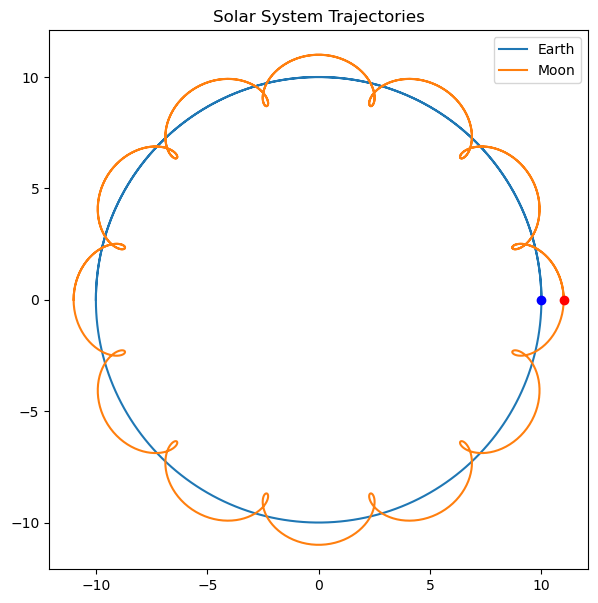

In [12]:
solar_system(3 * np.pi, 10, 11, 1, 13)

## Timing Matrix Operations

The computational cost of matrix operations depends on the size of the inputs. Below are pure-Python implementations of matrix–vector and matrix–matrix products, along with helper functions for generating random inputs.

In [13]:
def random_vector(n):
    """Generate a random vector of length n as a list."""
    return [random() for i in range(n)]


def random_matrix(n):
    """Generate a random nxn matrix as a list of lists."""
    return [[random() for j in range(n)] for i in range(n)]


def matrix_vector_product(A, x):
    """Compute the matrix-vector product Ax as a list."""
    m, n = len(A), len(x)
    return [sum([A[i][k] * x[k] for k in range(n)]) for i in range(m)]


def matrix_matrix_product(A, B):
    """Compute the matrix-matrix product AB as a list of lists."""
    m, n, p = len(A), len(B), len(B[0])
    return [[sum([A[i][k] * B[k][j] for k in range(n)])
             for j in range(p)]
            for i in range(m)]

## Problem 3

Use `time.time()` (or `%timeit`) to time `matrix_vector_product()` and `matrix_matrix_product()` for increasingly large $n \times n$ inputs. Generate random inputs with `random_matrix()` and `random_vector()` — time only the multiplication, not the generation.

Report your findings in a single figure with **two subplots**:
1. Matrix–vector multiplication times vs. $n$
2. Matrix–matrix multiplication times vs. $n$

Choose a domain for $n$ that clearly shows the growth rate without any single timing exceeding about 1 minute.

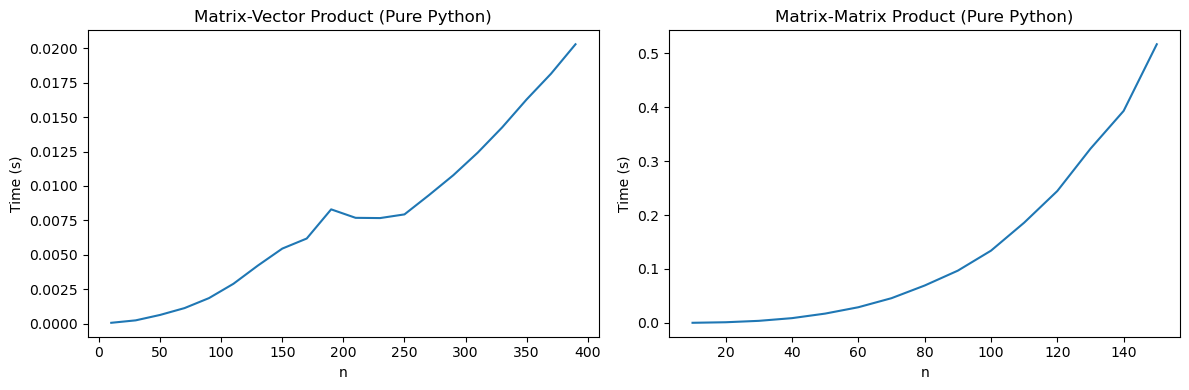

In [14]:
def prob3():
    """Time matrix_vector_product() and matrix_matrix_product() with increasingly
    large inputs. Report findings in a figure with two subplots: one for
    matrix-vector times and one for matrix-matrix times.
    """
    mv_sizes = list(range(10, 401, 20))
    mm_sizes = list(range(10, 151, 10))

    mv_times = []
    for n in mv_sizes:
        A, x = random_matrix(n), random_vector(n)
        start = time.time()
        matrix_vector_product(A, x)
        mv_times.append(time.time() - start)

    mm_times = []
    for n in mm_sizes:
        A, B = random_matrix(n), random_matrix(n)
        start = time.time()
        matrix_matrix_product(A, B)
        mm_times.append(time.time() - start)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(mv_sizes, mv_times)
    ax1.set_xlabel("n")
    ax1.set_ylabel("Time (s)")
    ax1.set_title("Matrix-Vector Product (Pure Python)")

    ax2.plot(mm_sizes, mm_times)
    ax2.set_xlabel("n")
    ax2.set_ylabel("Time (s)")
    ax2.set_title("Matrix-Matrix Product (Pure Python)")

    plt.tight_layout()
    plt.show()

prob3()

## Problem 4

Time `matrix_vector_product()`, `matrix_matrix_product()`, and `np.dot()` (for both matrix–vector and matrix–matrix) across the same range of $n$.

Report your findings in a **single figure with two subplots**:
1. All four sets of execution times on a **linear scale**
2. All four sets of execution times on a **log-log scale**

The log-log plot should reveal the algorithmic complexity: a line with slope $k$ on a log-log plot corresponds to $O(n^k)$ scaling.

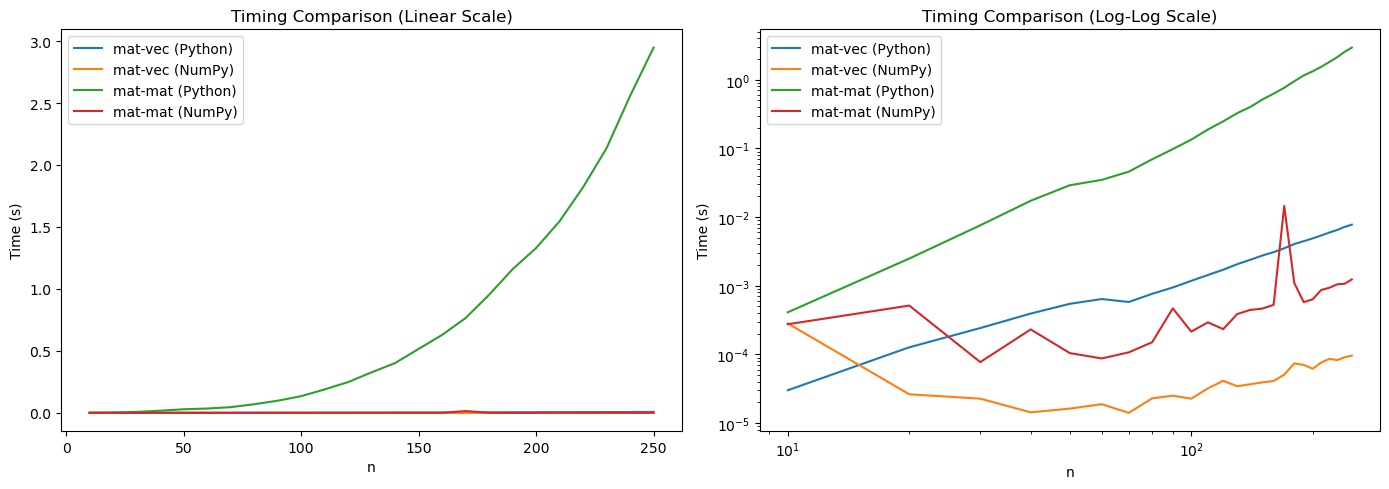

In [15]:
def prob4():
    """Time matrix_vector_product(), matrix_matrix_product(), and np.dot().
    Report findings in a figure with two subplots: one on a linear scale
    and one on a log-log scale, showing all four timing curves.
    """
    sizes = list(range(10, 251, 10))

    mv_py_times, mv_np_times = [], []
    mm_py_times, mm_np_times = [], []

    for n in sizes:
        A_list  = random_matrix(n)
        x_list  = random_vector(n)
        B_list  = random_matrix(n)
        A_np    = np.array(A_list)
        x_np    = np.array(x_list)
        B_np    = np.array(B_list)

        start = time.time()
        matrix_vector_product(A_list, x_list)
        mv_py_times.append(time.time() - start)

        start = time.time()
        np.dot(A_np, x_np)
        mv_np_times.append(time.time() - start)

        start = time.time()
        matrix_matrix_product(A_list, B_list)
        mm_py_times.append(time.time() - start)

        start = time.time()
        np.dot(A_np, B_np)
        mm_np_times.append(time.time() - start)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for ax in (ax1, ax2):
        ax.plot(sizes, mv_py_times, label="mat-vec (Python)")
        ax.plot(sizes, mv_np_times, label="mat-vec (NumPy)")
        ax.plot(sizes, mm_py_times, label="mat-mat (Python)")
        ax.plot(sizes, mm_np_times, label="mat-mat (NumPy)")
        ax.set_xlabel("n")
        ax.set_ylabel("Time (s)")
        ax.legend()

    ax1.set_title("Timing Comparison (Linear Scale)")
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_title("Timing Comparison (Log-Log Scale)")

    plt.tight_layout()
    plt.show()

prob4()